# B2 - Vannbølger

## Innføring i Fluidmekanikk (Uke 1)

Tilstand til et stoff (som vann, luft osv) i likevekt beskrives at to termodynamiske variabler, for eksempler tetthet $\rho$ og trykket $p$.

Erfaringen sier at fluider er sjelden i likevekt. Det håndteres stort sett sånt:

1. Tetthet $\rho(\vec{x},t)$ og $p(\vec{x},t)$ varierer i både tid og rom
2. Forflytting beskrives av et hastighetsfelt $\vec{u}(\vec{x},t)$, også avhengig av tid og rom.

Generelt finner vi $\rho, p, \vec{u}$ ved å løse partielle differensialligninger. Men først, litt om hva $\vec{u}$ egentlig sier.

## Hastighetsfelt (kinematikk)

Hastighetsfeltet $\vec{u}(\vec{x},t)$ beskriver endring av posisjon til en partikkel som befinner seg ved punkt $\vec{x}$ på tid $t$. Med andre ord, en partikkel som befinner seg i $\vec{x}_0$ ved tid $t=0$ følger en ordinær differensialligning:

$$
\frac{d}{dt}\vec{x}(t) = \vec{u}\big(\vec{x}(t),t\big), \quad \vec{x}(0) = \vec{x}_0
$$

## Eksempel: partikkel i et gitt felt

La

$$
\vec{u}(\vec{x},t) = A\vec{x}, \quad A = \begin{pmatrix}
0 & 1 \\
-1 & 0
\end{pmatrix}
$$

Da følger en partikkel $\vec{x}(t)$ som begynner ved $\vec{x}(0) = (1,0)$

$$
\vec{x}(t) = \begin{pmatrix}
\cos(t) \\
\sin(t)
\end{pmatrix}
$$

## Eksempel: tetthet i et gitt felt

Tetthet og andre egenskaper vil også flytte seg med feltet. Tetthet av en *inkompressibel* væske følger følgende ligning:

$$
\frac{\partial \rho}{\partial t} + \frac{\partial \rho}{\partial \vec{u}} = 0
$$

For kjent $\vec{u}(\vec{x},t)$ er det altså en bevaringslov.

**Eksempel**

Antar nå at vi har en-dimensjon i rom. La $\vec{u}(x,t)=a$ være konstant. Tettheten følger den transportligning

$$
\frac{\partial \rho}{\partial t} + a\frac{\partial \rho}{\partial x} = 0.
$$

## Oppgave 1: Fluidmekanikk


### a)

En partikkel $\vec{x}(t)$ beveger seg fra $\vec{x}(0) = (1,0)$ i det tidsavhengige feltet

$$
\vec{u}(\vec{x},t) = A(t)\vec{x}, \quad A(t) = \begin{pmatrix}
\cos(t) & \cos(t)+\sin(t) \\
-\sin(t) & 0
\end{pmatrix}
$$

Bruk Eulers metode til å spore posisjon til partikkelen over tid.

### b)

Antar den endimensjonal hastighet $\vec{u}(x,t)=2$. Hvis tettheten $\rho(x,0)=\frac{1}{1+x^2}$, hva er tettheten $\rho(x,t)$? 

## Løsning

### a) 

Koden kjøres under

### b) 

Vi har en ligning

$$
\frac{\partial\rho}{\partial t} + 2\frac{\partial\rho}{\partial x}
$$

Vi løser med karakteristikker:

En karakteristikk $x(t)$ løser $\dot{x}(t) = 2$, dvs $x(t)=x_0 + 2t$.

$\rho$ er konstant langs karakteristikker, altså $\rho(x(t),t))=\rho(x(0),0)=\rho(x(t)-2t,0)$. Vi har også

$$
\rho(x,t) = \frac{1}{1+(x-2t)^2}
$$

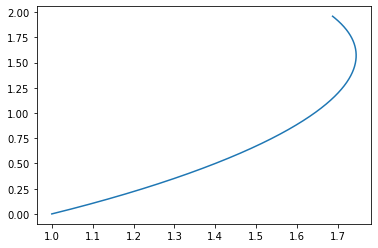

In [1]:
import matplotlib.pyplot as plt
import numpy as np

def A(t):
    return np.array([[np.cos(t),-np.sin(t)],[np.cos(t)+np.sin(t),0]])

def euler(f,x0,a,b,N):
    t = np.linspace(a,b,N)
    x = np.zeros((N,x0.size))
    x[0,:] = x0
    for i in np.arange(N-1):
        x[i+1,:] = x[i,:] + (t[i+1]-t[i])*(f(x[i],t[i]))
    return x,t

def f(x,t):
    return A(t) @ x

u0 = np.array([1,0])

u, t = euler(f, u0, 0, 1, 1000)

fig, ax = plt.subplots()

ax.plot(u[:,0],u[:,1])

## 2. Dynamikk (hvordan finne hastigheten)

Ligningen for $\vec{u}$ er mer komplisert (du får en million dollar om du løser den... https://no.wikipedia.org/wiki/Millenniumprisproblem), og mer et tema for matematikk 3. En liten smakbit på hvordan det funker i en dimensjon:

Grovt sett, kommer det fra en bevaringslov for *impuls*, $\rho u$, og i en dimensjon tar formen

$$
\frac{\partial u}{\partial t} + u\frac{\partial u}{\partial x} - \nu\frac{\partial^2 u}{\partial x^2} = -\frac{1}{\rho}\frac{\partial p}{\partial x}
$$

Hvis $\rho,p$ er kjent får vi en ligning som kombinerer både varmeligning og en (ikke-lineær) bevaringslov. Generelt er det konkurrende krefter:

1. Transport av impuls: $u\frac{\partial u}{\partial x}$ 
2. Dissipasjon fra viskositet: $-\nu\frac{\partial^2 u}{\partial x^2}$

Om 2 dominerer 1 kan vi faktisk bruke varmeligningen til å finne flyte: det heter *Stokes flow*.

Om 1 dominere 2 kan vi se bort fra viskositet og bruke bare bevaringsloven, da har vi *Eulers ligninger*.

Det er imidlertidig ikke alltid enkelt i dette tilfelle: det kan hende at selv om $\nu$ er veldig liten, at det kan fortsett ikke ignoreres i nærheten av en rand (ellers får vi ikke oppfylt randbetingelsene). Det kan vi se bort fra her.

## Oppgave 2: 

La oss anta at vi har konstant trykk $p$, slik at leddet på høyre siden over forsvinner, og vi får den såkalte (viskose) Burgers ligning:

$$
\frac{\partial u}{\partial t} + u\frac{\partial u}{\partial x} - \nu\frac{\partial^2 u}{\partial x^2} = 0
$$

La oss betrakte problemet hvor
$$
u(0,x) = \left\{
\begin{array}[cc]
& 2\quad & x<0 \\
0 \quad & x\geq 0
\end{array}
\right.
$$

### a)

Vis at ligningen løses av

$$
u(x,t) = \frac{2}{1+\exp\left(\frac{x-t}{\nu}\right)}
$$

### b)

Plott løsningen $u$ for forskjellige verdier av $\nu$. Hva skjer når $\nu\rightarrow 0$?

### c)

Sett opp en numerisk metode for ligningen basert på sentrale differanser i rom og forlengs Euler i tid. Bruk altså

$$
u_t(t_n,x_m) \approx \frac{u^{n+1}_m - u^n_m}{k}, \quad
u_x(t_n,x_m) \approx \frac{u^n_{m+1}-u^n_{m-1}}{2h}, \quad
u_{xx}(t_n,x_m) \approx \frac{u^n_{m+1}-2u^n_m + u^n_{m-1}}{h^2}
$$


### d)

Sammenlign den med Lax-Freidrichs metode på den ikke-viskøse ligning (med $\nu = 0$). Kan du finne en verdi for $\nu$ slik at de er like?

### e)

Kommenter samspill mellom viskositet og sjokk.

## Løsning

### a)

Vi la $u(x,t) = v(x+t) = f\big(g(x+t)\big)$, hvor

$$
f(x) = 2(1+x)^{-1},\quad g(x) = \exp(\frac{x}{\nu}).
$$

Da er $u_t = u_x = v'(x+t) = f'(g(x+t))\cdot g'(x+t)$

mens

$$u_{xx} = v''(x+t) = f''(g(x+t))\cdot g'(x+t)^2 + f'(g(x+t))g''(x+t)$$

Vi har

$$
g'(x+t) = \frac{1}{\nu} g(x+t) 
$$

som gir når vi setter inn

$$
u_x = -u_t = \frac{1}{\nu}f'(g) g
$$

og

$$
u_t + uu_x = \frac{1}{\nu}\big(-1+f(g)\big)\big(f'(g) g\big)
$$

mens

$$
\nu u_{xx} = \frac{1}{\nu} \big( f''(g)g^2 + f'(g)g \big) 
$$

Vi trenger altså

$$
f'(g) \big( -1 + f(g) \big) = f''(g)g + f'(g)
$$

for alle $g$.

Vi har

$$
f'(x) = -2(1+x)^{-2}, \quad f''(x) = 4(1+x)^{-3},
$$

Slik at venstresiden blir

$$
-2(1+g)^{-2}(-1 + 2(1+g)^{-1}) = 2(1+g)^{-2} - 4(1+g)^{-3}
$$

Mens høyresiden blir

$$
4(1+g)^{-3}g -2(1+g)^{-2}
$$

Ved å skrive

$$
\frac{1}{1+g} = \frac{1+g}{1+g} - \frac{g}{1+g} = 1 - \frac{g}{1+g} 
$$

Har vi

$$
(1+g)^{-3}g = (1+g)^{-2} - (1+g)^{-3}
$$

slik at høyresida blir

$$
2(1+g)^{-2} - 4(1+g)^{-3}
$$

som er lik venstresida.

### b)

Plottene vises under (for $t=0_+$, samme mønsteret bare flyttes bortover for andre $t$). Vi ser at vi får en "jevnet" versjon av trappefunksjonen idet $\nu\rightarrow 0$

### c)

Sentrale differanser:

$$
\begin{align*}
\frac{u^{n+1}_m-u^n_m}{k} &= -\frac{u^n_{m-1}+u^n_{m+1}}{2} \frac{u^n_{m+1}-u^n_{m-1}}{2h} + \nu \frac{u^{n+1}_m - 2u^n_m + u^{n-1}_m}{h^2} \\
\frac{u^{n+1}_m-u^n_m}{k} &= - \frac{1}{4h}\big((u^n_{m+1})^2-(u^n_{m-1})^2\big) + \frac{\nu}{h^2}\big(u^{n+1}_m - 2u^n_m + u^{n-1}_m\big)
\end{align*}
$$

### d)

Lax-Friedrichs:

$$
\begin{align*}
u^{n+1}_m &= \frac{1}{2}(u^n_{m+1} + u^n_{m-1}) - \frac{k}{2h}\big(\frac{1}{2}(u^n_{m+1})^2-\frac{1}{2}(u^n_{m-1})^2\big) \\
&= u^n_m + \frac{1}{2}(u^n_{m+1} - 2u^n_m + u^n_{m-1}) - \frac{k}{2h}\big(\frac{1}{2}(u^n_{m+1})^2-\frac{1}{2}(u^n_{m-1})^2\big) \\
\frac{u^{n+1}_m-u^n_m}{k} &= \frac{1}{2k}(u^n_{m+1} - 2u^n_m + u^n_{m-1}) - \frac{1}{4h}\big((u^n_{m+1})^2-(u^n_{m-1})^2\big)
\end{align*}
$$

Vi ser at metodene er det samme hvis $\nu = \frac{h^2}{2k}$, som vil gå mot null idet $h\rightarrow 0$. Lax-Friedrichs metoden tilfører altså "kunstig viskositet".

### e)

Viskositet utjevner sjokker. Mange numeriske metoder, inkludert Lax-Friedrichs, utjevner sjokk til en viss grad (ellers vil de bryte sammen).

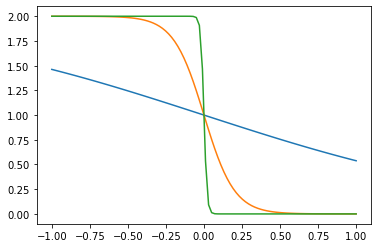

In [3]:
def u(x,nu):
    return 2 / (1 + np.exp(x/nu))

x = np.linspace(-1,1,100)

u1 = u(x,1)
u2 = u(x,0.1)
u3 = u(x,0.01)

fig, ax = plt.subplots()

ax.plot(x, u1)
ax.plot(x, u2)
ax.plot(x, u3)

## 3. Potentialflyte

Det virker som vi trenger stoff fra matte 3 til å se på alt annet en 1 dimensjon, som er veldig begrensende.

Heldigvis finnes det et spesielt tilfelle hvor vi kan finne $\vec{u}$ i flere dimensjoner ved hjelp av en skalar PDE, den kjente Laplaceligning!

Nå bruker vi det til å "oppgraderer" til flere dimensjoner i rom. Under gunstige forhold kan vi beskrive $\vec{u}$ med en skalar potentialfunksjon:

$$
u(x,y) = \nabla \phi,
$$

## Oppgave 3

Anta at vi er gitt

$$
\phi(x,y) = x \left( 1 + \frac{1}{x^2 + y^2} \right)
$$

### a)

Finn $\vec{u}$ og plott strømlinjer i feltet under.

### b)

Hva slags flyte representeres?

## Løsning


### a)

Vi skriver

$$
\phi = x + x(x^2+y^2)^{-1}
$$

slik at

$$
\frac{\partial f}{\partial x} = 1 + (x^2+y^2)^{-1} - 2x^2 (x^2 + y^2)^{-2}
$$

og

$$
\frac{\partial f}{\partial y} = -2xy (x^2 + y^2)^{-2}
$$

som plottes under

### b)

Det er flyte forbi en sirkulær gjenstand.

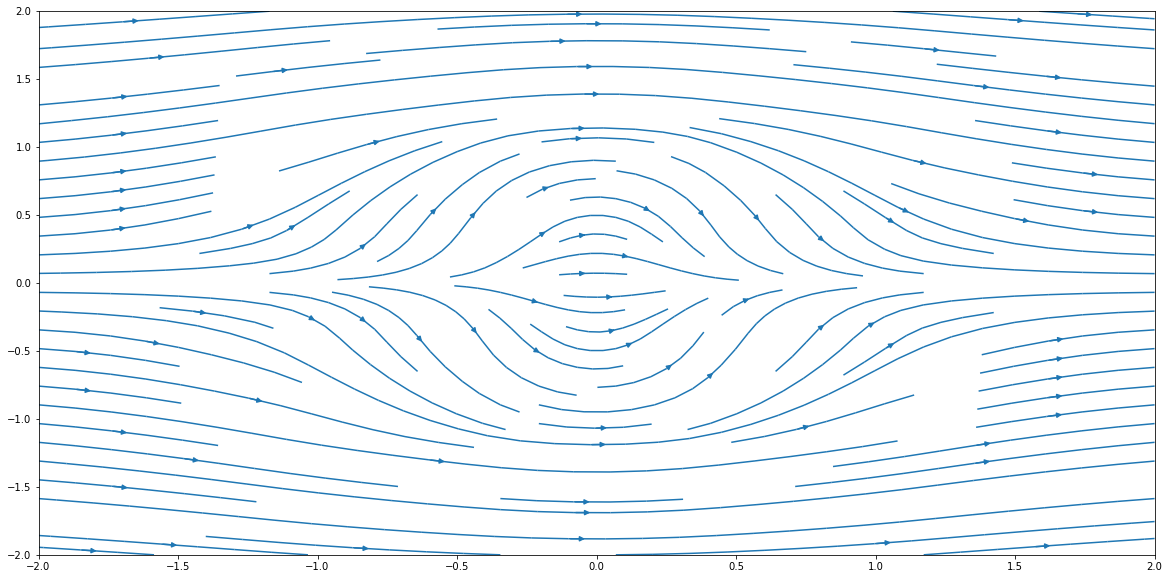

In [3]:
x = np.linspace(-2, 2, 6)
y = np.linspace(-2, 2, 6)
X, Y = np.meshgrid(x, y)

def f(x,y):
    x1 = 1 + 1/(x**2 + y**2) - 2*(x**2)/((x**2 + y**2)**2)
    x2 = -2*x*y/((x**2 + y**2)**2)
    return x1, x2

U, V = f(X,Y)


# plot
fig, ax = plt.subplots(figsize=(20,10))

ax.streamplot(X,Y, U, V)

plt.show()

## 4. Potentialflyte i en boks


Den store fordelen med å bruke en potential er at den oppfyller Laplaceligning

$$
\nabla^2 \phi = 0
$$

Randbetingelsene blir såkalte *Neumann* betingelser: vi oppgir $\frac{\partial \phi}{\partial\vec{n}}$ langs vegger med normalvektor 0. 

La oss anta at fluiden fyller en boks, med bare to inn- og ut- hull, hvor fluid kommer inn med kjent hastighet $a$ og ut med hastighet $b$.

Vi har da $\frac{\partial \phi}{\partial \vec{n}} = a$ eller $b$ ved åpningene, og ellers er $\frac{\partial \phi}{\partial\vec{n}} = 0$

## Oppgave 4

### a)

Løs ligningen numerisk for å finne $\phi$ 

### b)

Beregn $\phi_x$ og $\phi_y$ numerisk, og finn dermed $\vec{u}$.

### c)

Plott strømlinjer.

### d)

Hva kan du si om forholdet mellom $a,b$ og størrelsen på åpningene?

## Løsning

### a) 

Er under

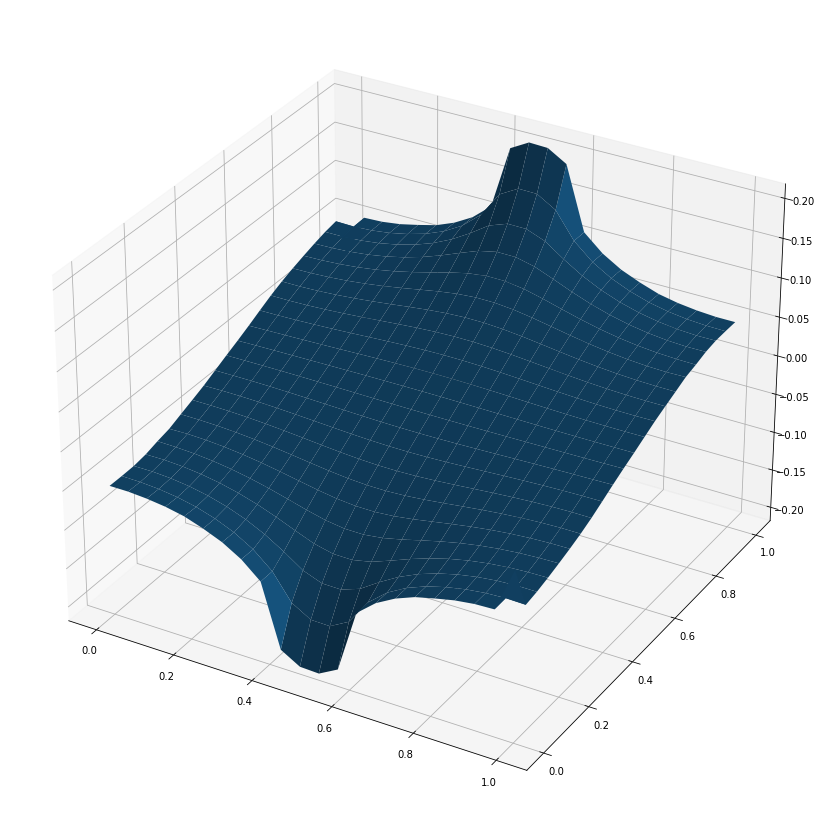

In [7]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as lin

# Uten randbetingelser

m=20

x=np.linspace(0,1,m+2)
h=x[1]-x[0]

L3 = (1/h**2)*sp.diags([1,-2,1],[-1,0,1],shape=(m+2,m+2))
I3 = sp.eye(m+2)

I3s = sp.csr_matrix(I3)

I3s[0,0]=0
I3s[-1,-1]=0

L3 = sp.csr_matrix(L3)

L3[0,0] = 0
L3[0,1] = 0
L3[-1,-1] = 0
L3[-1,-2] = 0

n=20

y=np.linspace(0,1,n+2)
k = y[1]-y[0]

L4 = (1/k**2)*sp.diags([1,-2,1],[-1,0,1],shape=(n+2,n+2))
I4 = sp.eye(n+2)

I4s = sp.csr_matrix(I4)

I4s[0,0] = 0
I4s[-1,-1] = 0

L4 = sp.csr_matrix(L4)

L4[0,0] = 0
L4[0,1] = 0
L4[-1,-1] = 0
L4[-1,-2] = 0

B1 = sp.kron(L3,I4s) 
B2 = sp.kron(I3s,L4)

# Legg til randbetingelser i matrisa

NB3 = np.zeros((m+2,m+2))
NB3[0,0] = -1/h
NB3[0,1] = 1/h
NB3[-1,-2] = -1/h
NB3[-1,-1] = 1/h

NB4 = np.zeros((n+2,n+2))
NB4[0,0] = -1/k
NB4[0,1] = 1/k
NB4[-1,-2] = -1/k
NB4[-1,-1] = 1/k

Nl = np.zeros((n+2,n+2))
Nl[0,0] = 1
Nl[-1,-1] = 1

Ml = np.zeros((m+2,m+2))
Ml[0,0] = 1
Ml[-1,-1] = 1

NB1 = sp.kron(NB3,I4) 
NB2 = sp.kron(I3,NB4)

B = B1 + B2 + NB1 + NB2

# Randbetingelse i forcing

Nm_l = np.zeros(m+2)
Nm_l[0] = 1

Nm_r = np.zeros(m+2)
Nm_r[-1] = 1

Nn_l = np.zeros(n+2)
Nn_l[0] = 1

Nn_r = np.zeros(n+2)
Nn_r[-1] = 1


def g1(x):
    if x>0.4 and x<0.6:
        return (x-0.4)*(x-0.6)
    else:
        return 0

def g2(x):
    if x>0.4 and x<0.6:
        return 1
    else:
        return 0

def g3(y):
        return 0*y

def g4(y):
        return 0*y

g1 = np.vectorize(g1)

g2 = np.vectorize(g2)

G1 = sp.kron(g2(x),Nn_l) 
G2 = sp.kron(g2(x),Nn_r) 
G3 = sp.kron(Nm_l,g3(y)) 
G4 = sp.kron(Nm_r,g4(y))

G = G1 + G2 + G3 + G4

G = G.toarray()

# Løs systemet

G2 = np.reshape(G,(m+2)*(n+2))

#print(G2)

v, istop, itn, r1norm = lin.lsqr(B, G2)[:4]

#print(v)

V = np.reshape(v,(m+2,n+2))

#print(V)

X, Y = np.meshgrid(x,y)

fig,ax2 = plt.subplots(subplot_kw ={"projection":"3d"}, figsize=(15,15))

ax2.plot_surface(np.transpose(X), np.transpose(Y), V) #vmin=Z.min() * 2, cmap=cm.Blues)

plt.show()

## Løsning (fort.)

### b)

og 

### c)

under:

(21, 21)
(21, 21)
(21, 21)


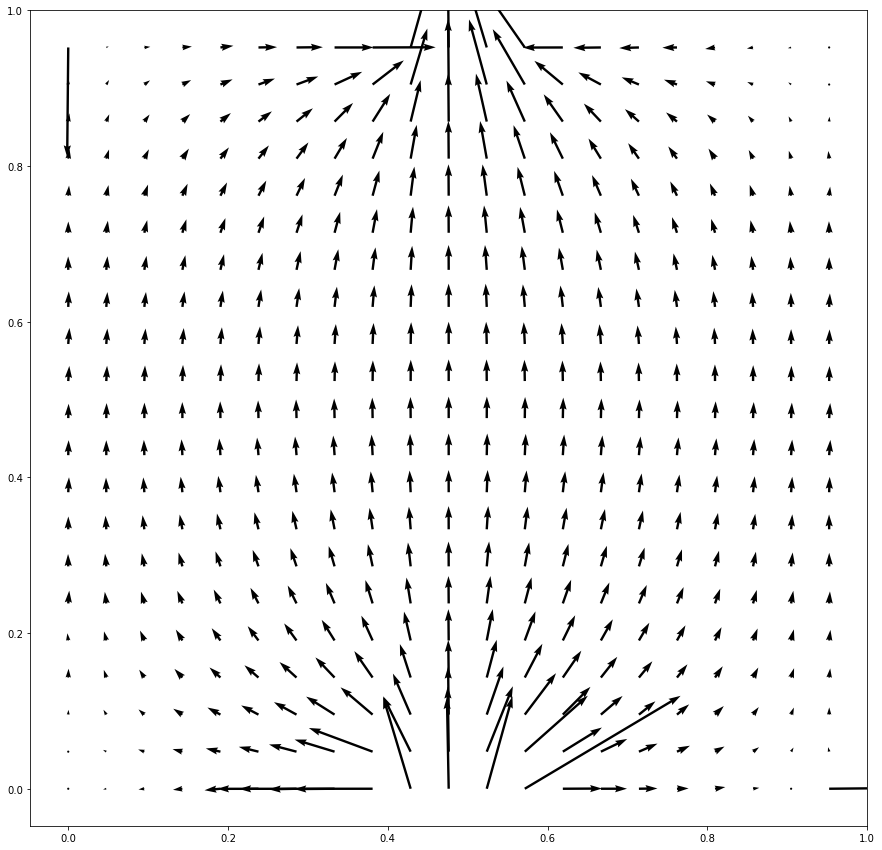

In [8]:
# Streamlines

# beregn gradient

V1 = np.diff(V, axis=0)
V2 = np.diff(V, axis=1)

print(V1[:,0:-1].shape)
print(V2[0:-1,:].shape)

print(X[0:-1,0:-1].shape)

# plott

fig, ax = plt.subplots(figsize=(15, 15))

ax.quiver(np.transpose(X[0:-1,0:-1]), np.transpose(Y[0:-1,0:-1]), V1[:,0:-1], V2[0:-1,:])

plt.show()

### d)

Vi kommer til å slite (ingen løsninger) hvis ikke fluks ut er lik fluks inn.

Vi får likevel en minst kvadraters løsning, men det er ikke egentlig det vi vil ha.

## 5. Frie overflater og bølger



Vi får stort sett Neumann randbetingelser: $\frac{\partial \phi}{\partial \vec{n}} = 0$ ved veggene. Men overflaten er mer komplisert:

La oss anta at vi har bølger med høyde $z=\zeta(x,t)$. Vi får...

$$
\frac{\partial \phi}{\partial z} = \frac{\partial \zeta}{\partial t}\quad \mathrm{hvor}\quad z=0
$$

Siden randbetingelsene endrer med tid gjør også $\phi$. Det viser seg at

$$
\frac{\partial \phi}{\partial t} = g\zeta
$$

## Oppgave 5

Det er egentlig en koblet system for $\phi,\zeta$, men en numerisk løsning for begge er ganske vanskelig. Vi fokuserer på løsning av $\phi$ for en gitt $\zeta$. Vi antar at

$$
\zeta(x,t) = \cos\big(x-\sqrt{gh}t\big)
$$

For hver tid $t$ har vi altså en Poisson ligning for $\phi$.

### a)

Plott $\zeta(x,t)$. Ser det ut som en passende bølge?

### b)

Løs ligningen for noen utvalgte tider $t$

### c)

Plott tilsværende strømlinjer (altså $\nabla\phi$)

### d)

Kommenter resultatene. Ser de ut som bølger?

## Løsning

### a)

Se kode under

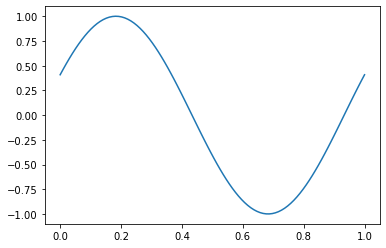

In [17]:
g = 10
h = 10

a = np.sqrt(g*h)


def gs(x,t):
    return np.cos(2*np.pi*x-a*t)

t = 1

xx = np.linspace(0,1,100)

plt.plot(xx, gs(xx,2))

### b)

Se under

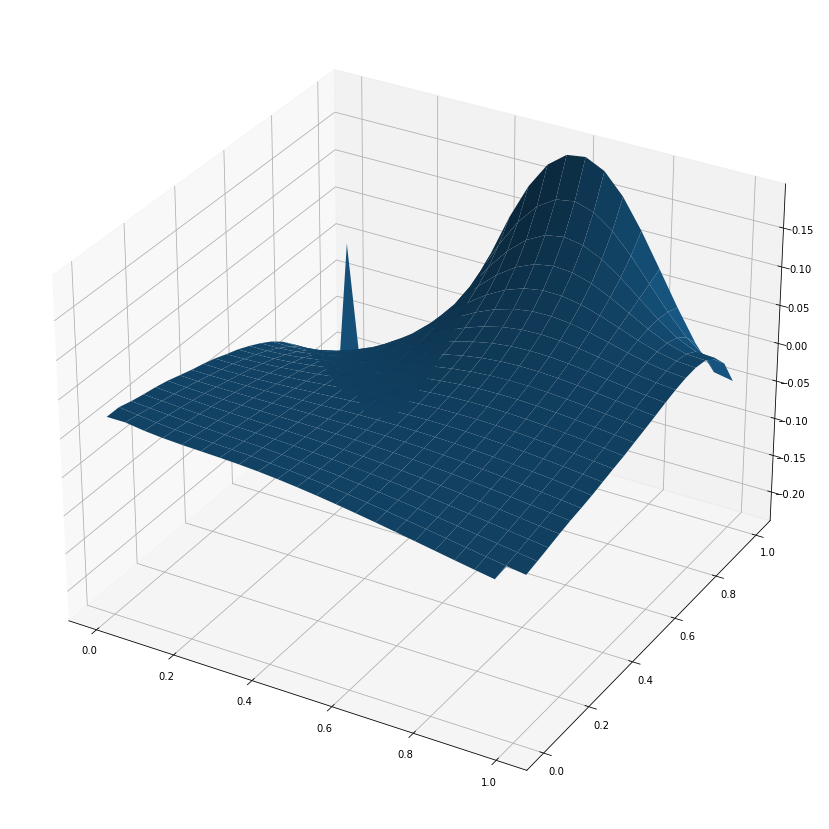

In [15]:
K1 = sp.kron(g3(x),Nn_l) 
K2 = sp.kron(gs(x,t),Nn_r) 
K3 = sp.kron(Nm_l,g3(y)) 
K4 = sp.kron(Nm_r,g4(y))

K = K1 + K2 + K3 + K4

K = K.toarray()

# Løs systemet

K2 = np.reshape(K,(m+2)*(n+2))

#print(G2)

w, istop, itn, r1norm = lin.lsqr(B, K2)[:4]

#print(v)

W = np.reshape(w,(m+2,n+2))

#print(V)

X, Y = np.meshgrid(x,y)

fig,ax2 = plt.subplots(subplot_kw ={"projection":"3d"}, figsize=(15,15))

ax2.plot_surface(np.transpose(X), np.transpose(Y), W) #vmin=Z.min() * 2, cmap=cm.Blues)

plt.show()

### c)

Se under

### d)

Virker rimelig til meg!

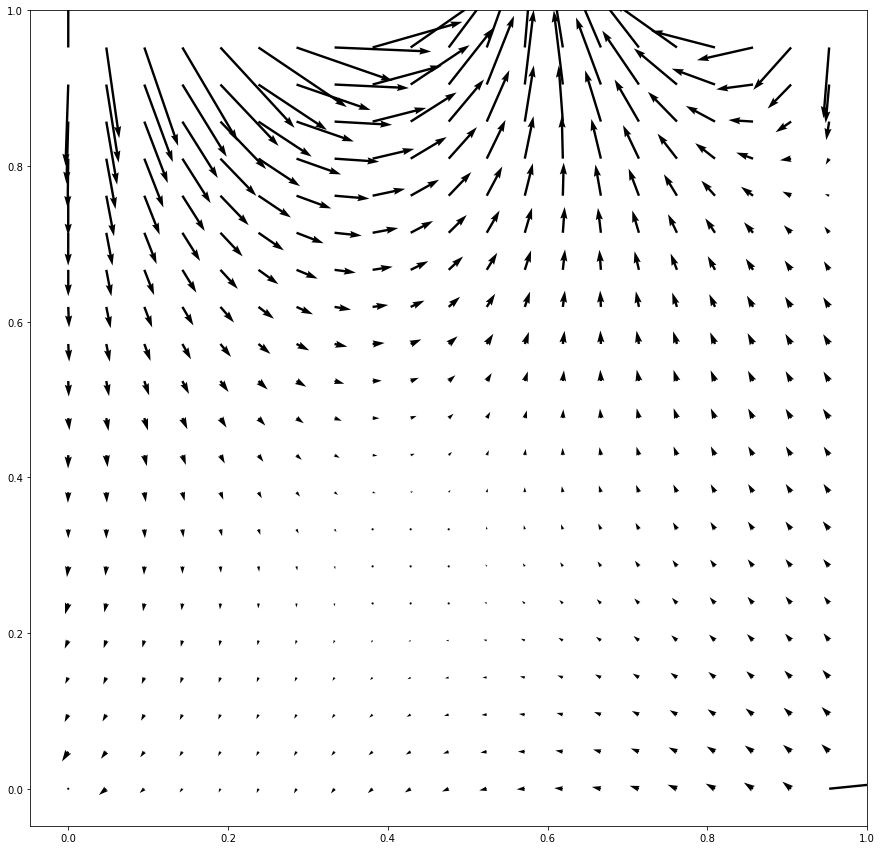

In [16]:
# Streamlines

W1 = np.diff(W, axis=0)
W2 = np.diff(W, axis=1)

fig, ax = plt.subplots(figsize=(15, 15))

ax.quiver(np.transpose(X[0:-1,0:-1]), np.transpose(Y[0:-1,0:-1]), W1[:,0:-1], W2[0:-1,:])

plt.show()

## Oppgave 6: Fourieranalyse og bølger

For å forstå mer hvor $\zeta$ kommer fra er vi nødt til å tie til bølgelære. Særlig ideer beslektet med Fourieranalyse skal være nyttig her. 

1. Bruk separasjon av variabler på ligningen fra oppgave i 5 til å vise at

$$
\phi(x,z,t) = \phi(z)\exp(i(kx-\sigma t)),\quad \zeta = \zeta \exp(i(kx-\sigma t)
$$

hvor

$$
\sigma^2 = gk \tanh kh
$$

*Hint: randbetingelsene*

$$
\frac{\partial \phi}{\partial t} = g\zeta
$$

*kan skrives om til*

$$
\frac{\partial^2 \phi}{\partial t^2} + g\frac{\partial \phi}{\partial z} = 0
$$

2. Velg verdier for $k$ og $h$ og finn $\Phi$ og og $\nabla\Phi$.

3. Bruk resultatet til å spore ferden til en partikkel som begynner ved overflaten i tid $t=0$.